In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn import neural_network
from sklearn.metrics import confusion_matrix

import itertools


def apply_sepia(image):
    r = image[:, :, 0]
    g = image[:, :, 1]
    b = image[:, :, 2]
    new_r = np.clip(r * 0.393 + g * 0.769 + b * 0.189, 0, 255)
    new_g = np.clip(r * 0.349 + g * 0.686 + b * 0.168, 0, 255)
    new_b = np.clip(r * 0.272 + g * 0.534 + b * 0.131, 0, 255)
    sepia_img = np.stack([new_r, new_g, new_b], axis=2).astype(np.uint8)
    return sepia_img

def create_dataset():
    from sklearn.datasets import load_digits
    data = load_digits()
    images_gray = data.images

    inputs = []
    outputs = []

    for img_gray in images_gray:
        img_norm = (img_gray / img_gray.max() * 255).astype(np.uint8)
        img_rgb = np.stack([img_norm, img_norm, img_norm], axis=2)

        inputs.append(img_rgb.flatten().tolist())
        outputs.append(0)

        img_sepia = apply_sepia(img_rgb)
        inputs.append(img_sepia.flatten().tolist())
        outputs.append(1)

    outputNames = ['normal', 'sepia']
    print(f"Total exemple: {len(inputs)} ({len(inputs)//2} normale + {len(inputs)//2} sepia)")
    return inputs, outputs, outputNames

inputs, outputs, outputNames = create_dataset()

def splitData(inputs, outputs):
    np.random.seed(5)
    indexes = [i for i in range(len(inputs))]
    trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace=False)
    testSample = [i for i in indexes if i not in trainSample]
    trainInputs = [inputs[i] for i in trainSample]
    trainOutputs = [outputs[i] for i in trainSample]
    testInputs = [inputs[i] for i in testSample]
    testOutputs = [outputs[i] for i in testSample]
    return trainInputs, trainOutputs, testInputs, testOutputs

def normalisation(trainData, testData):
    scaler = StandardScaler()
    if not isinstance(trainData[0], list):
        trainData = [[d] for d in trainData]
        testData = [[d] for d in testData]
        scaler.fit(trainData)
        normalisedTrainData = scaler.transform(trainData)
        normalisedTestData = scaler.transform(testData)
        normalisedTrainData = [el[0] for el in normalisedTrainData]
        normalisedTestData = [el[0] for el in normalisedTestData]
    else:
        scaler.fit(trainData)
        normalisedTrainData = scaler.transform(trainData)
        normalisedTestData = scaler.transform(testData)
    return normalisedTrainData, normalisedTestData

def plotConfusionMatrix(cm, classNames, title):
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title('Confusion Matrix ' + title)
    plt.colorbar()
    tick_marks = np.arange(len(classNames))
    plt.xticks(tick_marks, classNames, rotation=45)
    plt.yticks(tick_marks, classNames)
    text_format = 'd'
    thresh = cm.max() / 2.
    for row, column in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(column, row, format(cm[row, column], text_format),
                 horizontalalignment='center',
                 color='white' if cm[row, column] > thresh else 'black')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

def evalMultiClass(realLabels, computedLabels, labelNames):
    conf_matrix = confusion_matrix(realLabels, computedLabels)
    accuracy = sum([conf_matrix[i][i] for i in range(len(labelNames))]) / len(realLabels)
    precision = {}
    rec = {}
    for i in range(len(labelNames)):
        precision[labelNames[i]] = conf_matrix[i][i] / sum([conf_matrix[j][i] for j in range(len(labelNames))])
        rec[labelNames[i]] = conf_matrix[i][i] / sum([conf_matrix[i][j] for j in range(len(labelNames))])
    return accuracy, precision, rec, conf_matrix




Total exemple: 3594 (1797 normale + 1797 sepia)


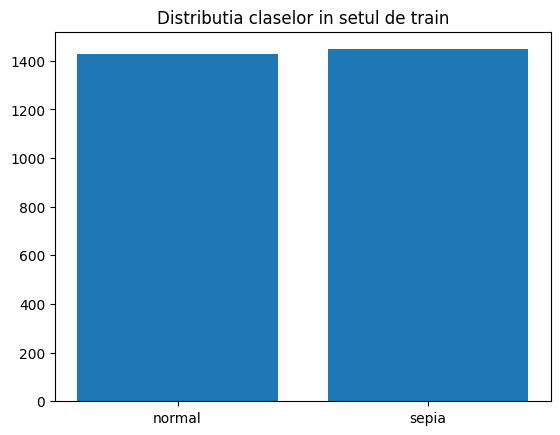

Train: 2875 exemple | Test: 719 exemple
Model antrenat.


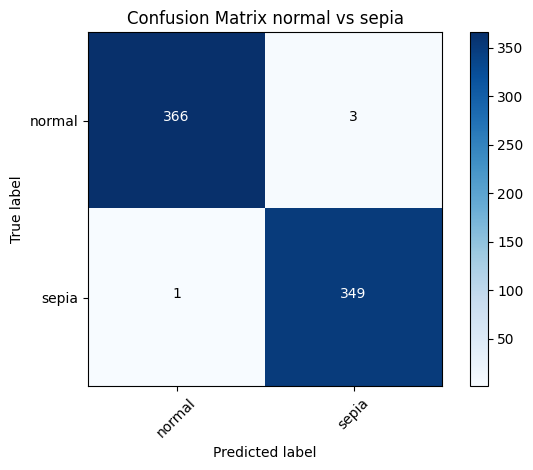


=== Rezultate model default (hidden_layer_sizes=(100,)) ===
Accuracy:  0.9944
Precision: {'normal': np.float64(0.997275204359673), 'sepia': np.float64(0.9914772727272727)}
Recall:    {'normal': np.float64(0.991869918699187), 'sepia': np.float64(0.9971428571428571)}


In [10]:
trainInputs, trainOutputs, testInputs, testOutputs = splitData(inputs, outputs)

bins = range(len(outputNames) + 1)
plt.hist(trainOutputs, bins, rwidth=0.8)
bin_w = (max(bins) - min(bins)) / (len(bins) - 1)
plt.xticks(np.arange(min(bins) + bin_w / 2, max(bins), bin_w), outputNames)
plt.title("Distributia claselor in setul de train")
plt.show()

trainInputs, testInputs = normalisation(trainInputs, testInputs)
print(f"Train: {len(trainInputs)} exemple | Test: {len(testInputs)} exemple")

classifier = neural_network.MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    max_iter=200,
    solver='sgd',
    random_state=1,
    learning_rate_init=0.1
)
classifier.fit(trainInputs, trainOutputs)
print("Model antrenat.")

predictedLabels = classifier.predict(testInputs)

acc, prec, recall, cm = evalMultiClass(np.array(testOutputs), predictedLabels, outputNames)

plotConfusionMatrix(cm, outputNames, "normal vs sepia")

print("\n=== Rezultate model default (hidden_layer_sizes=(100,)) ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec}")
print(f"Recall:    {recall}")

  HL=(10,), iter=100, lr=0.1 => acc=0.9972
  HL=(100,), iter=100, lr=0.1 => acc=0.9944
  HL=(100, 50), iter=100, lr=0.1 => acc=0.9972
  HL=(100,), iter=200, lr=0.1 => acc=0.9944
  HL=(100,), iter=100, lr=0.01 => acc=0.9986
  HL=(100,), iter=100, lr=0.5 => acc=0.9930


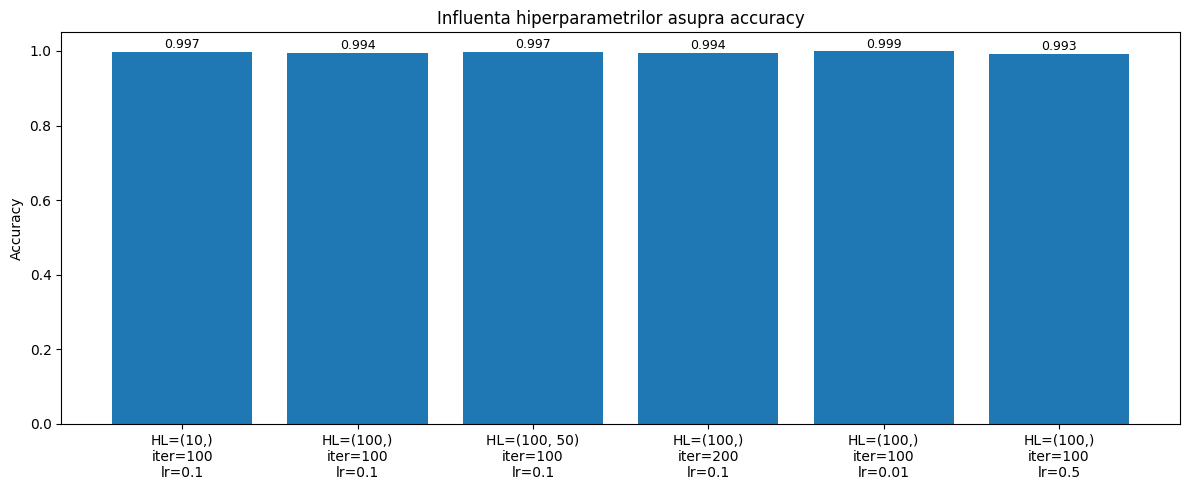

In [11]:

configs = [
    {"hidden_layer_sizes": (10,),       "max_iter": 100, "learning_rate_init": 0.1},
    {"hidden_layer_sizes": (100,),      "max_iter": 100, "learning_rate_init": 0.1},
    {"hidden_layer_sizes": (100, 50),   "max_iter": 100, "learning_rate_init": 0.1},
    {"hidden_layer_sizes": (100,),      "max_iter": 200, "learning_rate_init": 0.1},
    {"hidden_layer_sizes": (100,),      "max_iter": 100, "learning_rate_init": 0.01},
    {"hidden_layer_sizes": (100,),      "max_iter": 100, "learning_rate_init": 0.5},
]

results = []
for cfg in configs:
    clf = neural_network.MLPClassifier(
        hidden_layer_sizes=cfg["hidden_layer_sizes"],
        activation='relu',
        max_iter=cfg["max_iter"],
        solver='sgd',
        random_state=1,
        learning_rate_init=cfg["learning_rate_init"]
    )
    clf.fit(trainInputs, trainOutputs)
    preds = clf.predict(testInputs)
    a, _, _, _ = evalMultiClass(np.array(testOutputs), preds, outputNames)
    results.append((cfg, a))
    print(f"  HL={cfg['hidden_layer_sizes']}, iter={cfg['max_iter']}, lr={cfg['learning_rate_init']} => acc={a:.4f}")

labels_plot = [
    f"HL={c['hidden_layer_sizes']}\niter={c['max_iter']}\nlr={c['learning_rate_init']}"
    for c, _ in results
]
accs_plot = [a for _, a in results]

plt.figure(figsize=(12, 5))
plt.bar(range(len(results)), accs_plot, tick_label=labels_plot)
plt.ylabel("Accuracy")
plt.title("Influenta hiperparametrilor asupra accuracy")
plt.ylim(0, 1.05)

for i, v in enumerate(accs_plot):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


In [15]:
from myNN import NN

X_train = np.array(trainInputs)
y_train = np.array(trainOutputs)
X_test = np.array(testInputs)
y_test = np.array(testOutputs)
model_custom = NN(n_features=X_train.shape[1], n_classes=len(outputNames), n_hidden=4)
model_custom.fit(X_train, y_train, reg=0.001, max_iters=10, eta=0.5)
preds_custom = model_custom.predict(X_test)
acc, prec, recall, cm = evalMultiClass(y_test, preds_custom, outputNames)


Iteratia 0: loss 0.6931


Accuracy:  0.6912
Precision: {'normal': np.float64(0.8418604651162791), 'sepia': np.float64(0.626984126984127)}
Recall:    {'normal': np.float64(0.4905149051490515), 'sepia': np.float64(0.9028571428571428)}


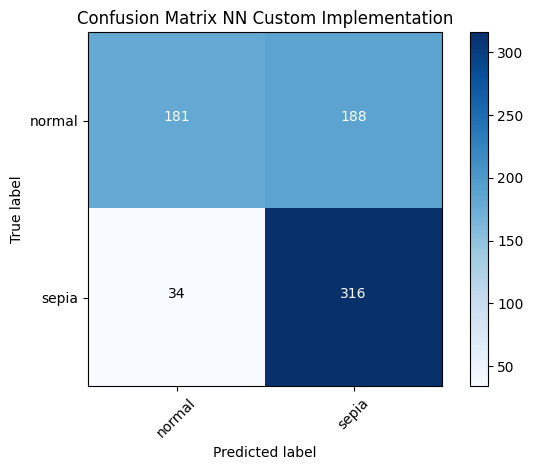

In [16]:
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec}")
print(f"Recall:    {recall}")
plotConfusionMatrix(cm, outputNames, "NN Custom Implementation")